In [1]:
from google.colab import files

uploaded = files.upload()

Saving decode2.csv to decode2 (1).csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("decode2.csv")

df = df[["Pclass","Sex","Age","SibSp","Parch","Fare","Survived"]]

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male":0,"female":1})

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))


Accuracy: 0.8044692737430168


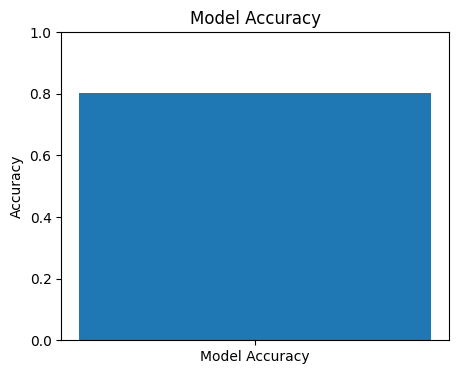

In [3]:
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, pred)

plt.figure(figsize=(5,4))
plt.bar(["Model Accuracy"], [accuracy])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

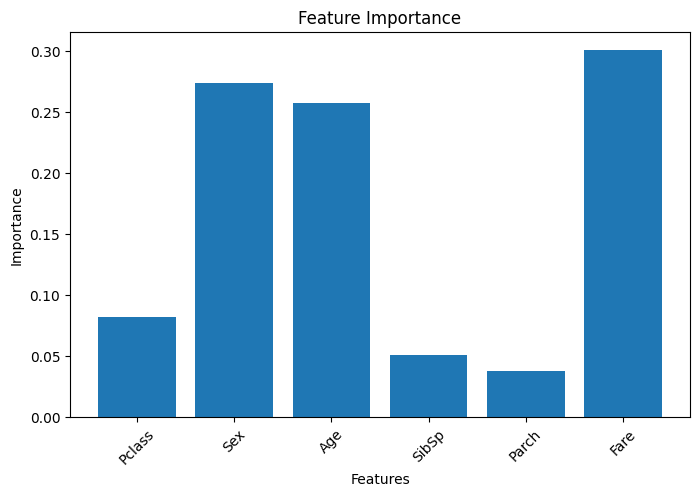

In [4]:
import matplotlib.pyplot as plt

features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, model.feature_importances_)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

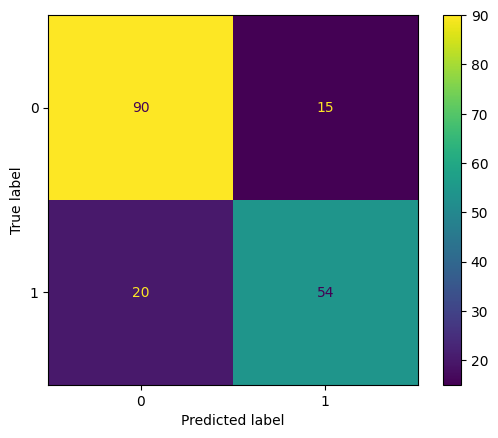

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

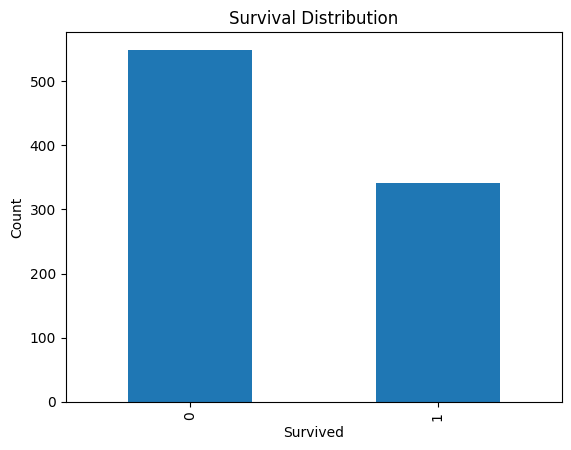

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()